## Linear Regression using ScikitLearn and Regression Metrics

---

### 1.0 Import warnings

In [1]:
# Importing the warnings library to manage warning messages
import warnings

# Configuring the warnings module to ignore all warning messages
warnings.filterwarnings("ignore")

---

### 2.0 Import necessary libraries

In [2]:
# Importing the matplotlib library for data visualization
import matplotlib.pyplot as plt

# Importing the pandas library for data manipulation and analysis
import pandas as pd

# Importing the numpy library for numerical operations
import numpy as np

# Importing the train_test_split function to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Importing the LinearRegression class to create and train a linear regression model
from sklearn.linear_model import LinearRegression

# Importing necessary metrics from the sklearn library for model evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

---

### 3.0 Import Data

In [3]:
# Define the directory where the data is present
dir = r"C:\Users\SESA702302\OneDrive - Schneider Electric\Personal\0.0 Data Science Personal\23.0 Linear Regression\1.0 Input"

In [4]:
df = pd.read_csv(dir+'\\placement.csv')

---

### 4.0 Exploratory Data Analysis

In [5]:
# Have a look at the data
print(df.shape)
df.head()

(200, 2)


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [6]:
# Check for NULL values
df.isnull().sum()

cgpa       0
package    0
dtype: int64

Text(0, 0.5, 'Package(in lpa)')

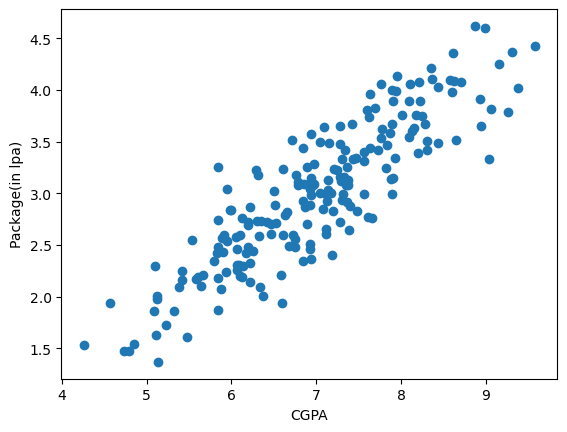

In [7]:
# Plot the data to see whether the data is linear or not
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

- The data is not completly linear, but sort of linear

---

### 5.0 Data Preprocessing


#### 5.1 Extracting the Independent and Dependent features

In [8]:
# Selecting the feature (independent variable) from the DataFrame, using all rows and the first column
X = df.iloc[:, 0:1]

# Selecting the target variable (dependent variable) from the DataFrame, using all rows and the last column
y = df.iloc[:, -1]

#### 5.2 Splitting the data into train and test

In [9]:
# Splitting the dataset into training and testing sets
# X_train and y_train will be used for training the model
# X_test and y_test will be used for evaluating the model's performance

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#### 5.3 Fitting the Linear Regression Model

In [10]:
# Creating an instance of the Linear Regression model
lr = LinearRegression()

# Fitting the model to the training data (X_train features and y_train target)
lr.fit(X_train, y_train)

LinearRegression()

#### 5.4 Making Prediction

In [11]:
# Using the trained linear regression model to make predictions on the test data (X_test)
y_pred = lr.predict(X_test)

In [12]:
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

#### 5.5 Displaying the Best fit line

Text(0, 0.5, 'Package (in lpa)')

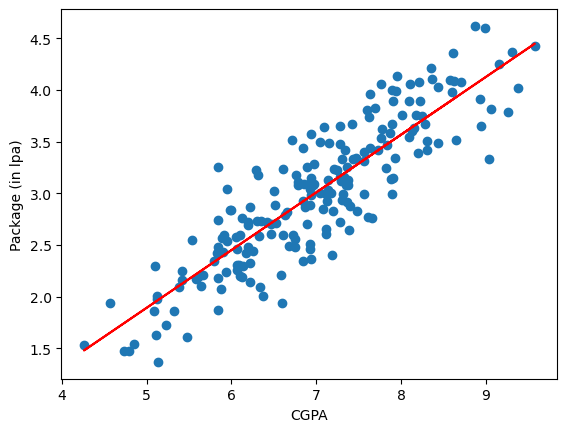

In [13]:
# Creating a scatter plot of CGPA vs. Package from the DataFrame
plt.scatter(df['cgpa'], df['package'])

# Plotting the predicted linear regression line based on the training data
plt.plot(X_train, lr.predict(X_train), color='red')

# Labeling the x-axis as 'CGPA'
plt.xlabel('CGPA')

# Labeling the y-axis as 'Package (in lpa)'
plt.ylabel('Package (in lpa)')

#### 5.6 Getting the Model parameters

In [13]:
# Extracting the coefficients (slope) of the linear regression model
m = lr.coef_

# Extracting the intercept (y-intercept) of the linear regression model
b = lr.intercept_

In [15]:
b

-0.8961119222429144

In [14]:
m

array([0.55795197])

#### 5.7 Getting the equation for Best fit line

In [18]:
# y = mx + b

y = m * 5.89 + b
y

array([2.3902252])

In [16]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


---

### 6. Regression Metrics

#### 6.1 MAE

In [19]:
print("MAE:",mean_absolute_error(y_test,y_pred))

MAE: 0.2884710931878175


#### 6.2 MSE

In [20]:
print("MSE:",mean_squared_error(y_test,y_pred))

MSE: 0.12129235313495527


#### 6.3 RMSE

In [21]:
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE: 0.34827051717731616


#### 6.4 R-Squared

In [19]:
r2 = r2_score(y_test,y_pred)
print("R-Squared:",r2)

R-Squared: 0.780730147510384


#### 6.5 Adjusted R-Squared

In [20]:
print("Adjusted R-Squared:", 1 - ((1-r2)*(40-1)/(40-1-1)))

Adjusted R-Squared: 0.7749598882343415


---

### 7.0 Adding an irrelevant column to see the effect on R-squared and Adj R-squared

In [21]:
# Create a copy of the original DataFrame 'df' to avoid modifying it directly
new_df1 = df.copy()

# Add a new column 'random_feature' to 'new_df1' with 200 random values between 0 and 1
new_df1['random_feature'] = np.random.random(200)

# Select specific columns ('cgpa', 'random_feature', and 'package') to include in the new DataFrame
new_df1 = new_df1[['cgpa', 'random_feature', 'package']]

# Display the first few rows of the newly created DataFrame 'new_df1'
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.549833,3.26
1,5.12,0.012929,1.98
2,7.82,0.545248,3.25
3,7.42,0.757300,3.67
4,6.94,0.240797,3.57


Text(0, 0.5, 'Package (in lpa)')

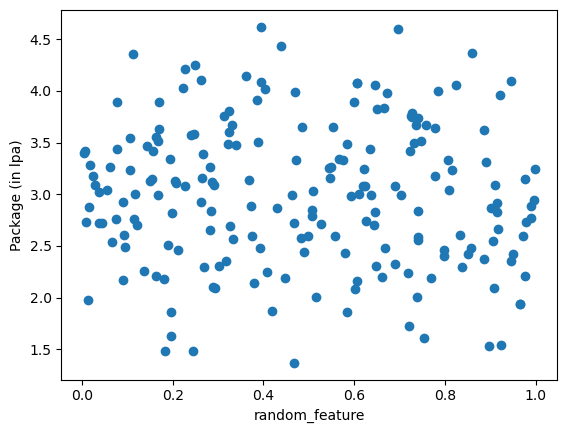

In [22]:
# Create a scatter plot using 'random_feature' on the x-axis and 'package' on the y-axis
plt.scatter(new_df1['random_feature'], new_df1['package'])

# Label the x-axis as 'random_feature'
plt.xlabel('random_feature')

# Label the y-axis as 'Package (in lpa)' to indicate the units
plt.ylabel('Package (in lpa)')

In [23]:
# Select the first two columns (features) from 'new_df1' and assign to X
X = new_df1.iloc[:, 0:2]

# Select the last column (target variable) from 'new_df1' and assign to y
y = new_df1.iloc[:, -1]

# Split the dataset into training and testing sets
# 80% of the data will be used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create an instance of the Linear Regression model
lr = LinearRegression()

# Fit the Linear Regression model to the training data
lr.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = lr.predict(X_test)

In [24]:
# Calculate the R-squared score to evaluate the model's performance
r2 = r2_score(y_test, y_pred)

# Print the R-squared value
print("R-Squared:", r2)

# Calculate the Adjusted R-squared value
# Adjusted R-squared accounts for the number of predictors in the model
# Here, 40 is the total number of observations, and 2 is the number of predictors used
print("Adj. R-Squared:", 1 - ((1-r2)*(40-1)/(40-1-2)))

R-Squared: 0.7844107624908375
Adj. R-Squared: 0.772757290193045


In [25]:
((0.7733269209249535-0.7610743220560321)/0.7733269209249535)*100

1.584400922480031

- Since the column that we added was irrelvant, therefore Adj. R-Squred decreased compared to R-Squared meanining that the new column has very less impact on the model

---

### 8.0 Adding a relevant column to see the effect on R-squared and Adj R-squared

In [26]:
# Create a copy of the original DataFrame 'df' to avoid modifying it directly
new_df2 = df.copy()

# Add a new column 'iq' to 'new_df2' 
# This column is calculated by adding a random adjustment (between -1.2 and 1.2) to the 'package' column
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, 200) / 10)

# Select specific columns ('cgpa', 'iq', and 'package') to include in the new DataFrame
new_df2 = new_df2[['cgpa', 'iq', 'package']]

Text(0, 0.5, 'Package (in lpa)')

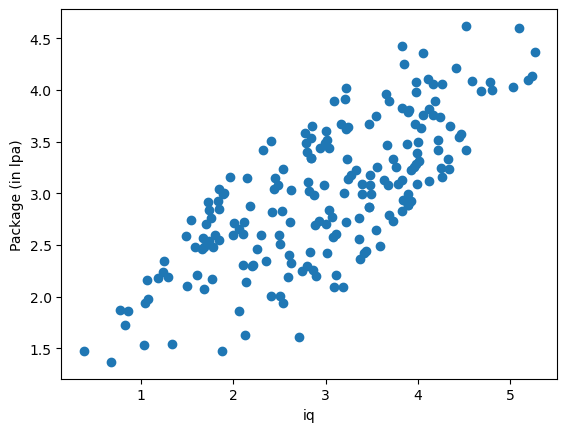

In [27]:
# Create a scatter plot using 'iq' on the x-axis and 'package' on the y-axis
plt.scatter(new_df2['iq'], new_df2['package'])

# Label the x-axis as 'iq' to indicate the variable being plotted
plt.xlabel('iq')

# Label the y-axis as 'Package (in lpa)' to indicate the units of the package
plt.ylabel('Package (in lpa)')

In [28]:
# Select the first two columns (features) from 'new_df2' and assign to X
X = new_df2.iloc[:, 0:2]

# Select the last column (target variable) from 'new_df2' and assign to y
y = new_df2.iloc[:, -1]

In [29]:
# Split the dataset into training and testing sets
# 80% of the data will be used for training (X_train, y_train) and 20% for testing (X_test, y_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create an instance of the Linear Regression model
lr = LinearRegression()

# Fit the Linear Regression model to the training data (X_train and y_train)
lr.fit(X_train, y_train)

# Use the trained model to make predictions on the test set (X_test)
y_pred = lr.predict(X_test)

In [30]:
# Calculate the R-squared score to evaluate the model's performance
r2 = r2_score(y_test, y_pred)

# Print the R-squared value
print("R-Squared:", r2)

# Calculate the Adjusted R-squared value
# Adjusted R-squared accounts for the number of predictors in the model
# Here, 40 is the total number of observations, and 2 is the number of predictors used
print("Adj. R-Squared:", 1 - ((1-r2)*(40-1)/(40-1-2)))

R-Squared: 0.8621026289703264
Adj. R-Squared: 0.8546487170227764


In [23]:
((0.7988832494468918-0.7880120737413184)/0.7988832494468918)*100

1.3607965510730216